In [18]:
import os, re, numpy as np, torch

from typing import List, Tuple
from datetime import datetime
from matplotlib import pyplot as plt
from sklearn.decomposition import PCA
from sklearn.feature_selection import mutual_info_classif
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim

from config import load_config
from model import CommonViT
from pipeline import NpyHSDataset

config = load_config()
data_path = config.path.data

In [19]:
dataset = NpyHSDataset(config)

[14:59:25] loading patients...
[14:59:26]   loaded 1/163: BaoYu_20241206_RD1.npy (baoyu), shape (512, 512, 64), non-bg pixels: 13,518, possesses non_bg labels: [0 1 3 5 7], max label 7, min label 0
[14:59:26]   loaded 2/163: BaoYu_20241206_RU.npy (baoyu), shape (512, 512, 64), non-bg pixels: 28,190, possesses non_bg labels: [0 1 2 3 5], max label 5, min label 0
[14:59:27]   loaded 3/163: Cuiyufen_20250326_LUD.npy (cuiyufen), shape (512, 512, 64), non-bg pixels: 788, possesses non_bg labels: [0 1 2], max label 2, min label 0
[14:59:27]   loaded 4/163: Dongruichun_20250211_LU.npy (dongruichun), shape (512, 512, 64), non-bg pixels: 29,044, possesses non_bg labels: [0 1 3 7], max label 7, min label 0
[14:59:28]   loaded 5/163: Dongruichun_20250211_RU.npy (dongruichun), shape (512, 512, 64), non-bg pixels: 90,036, possesses non_bg labels: [0 1 3 4 5], max label 5, min label 0
[14:59:29]   loaded 6/163: Fangkun_20250310_LD.npy (fangkun), shape (512, 512, 64), non-bg pixels: 557, possesses no

In [22]:
dataset.patches

112

In [13]:
class PatchDataset(Dataset):
    def __init__(self, patch_indices, patch_labels, patient_data, patient_label_maps, patch_size):
        self.patch_indices = patch_indices
        self.patch_labels = patch_labels
        self.patient_data = patient_data
        self.patient_label_maps = patient_label_maps
        self.patch_size = patch_size
        self.margin = patch_size // 2
    
    def __len__(self):
        return len(self.patch_indices)
    
    def __getitem__(self, idx):
        patient_idx, row, col = self.patch_indices[idx]
        patch = self.patient_data[patient_idx][
            row - self.margin : row + self.margin + 1,
            col - self.margin : col + self.margin + 1,
            :
        ]
        label_patch = self.patient_label_maps[patient_idx][
            row - self.margin : row + self.margin + 1,
            col - self.margin : col + self.margin + 1
        ]
        return patch, label_patch
    
def tprint(*args, **kwargs):
    """Print with [HH:MM:SS] timestamp prefix."""
    print(datetime.now().strftime('[%H:%M:%S]'), *args, **kwargs)
    
def _pair_data_and_labels() -> List[Tuple[str, str]]:
    data_path = config.path.data
    # sorted() ensures deterministic file order across OS/filesystems
    all_files = sorted(os.listdir(data_path))

    # Filter for .npy files and pair them
    data_files = [f for f in all_files if f.endswith('.npy') and not f.endswith('_gt.npy')]
    label_files = [f for f in all_files if f.endswith('_gt.npy')]
    
    pairs = []
    for data_file in data_files:
        base_name = data_file[:-4]  # Remove .npy extension
        label_file = base_name + '_gt.npy'
        if label_file in label_files:
            pairs.append((os.path.join(data_path, data_file), os.path.join(data_path, label_file)))
        else:
            tprint(f"Warning: No label file found for {data_file}")
    return pairs

def _extract_patient_id(filepath: str) -> str:
    basename = os.path.basename(filepath)
    match = re.match(r'^(.+?)_(\d{8})_', basename)
    if match:
        return match.group(1).lower()
    # Fallback: use basename without extension
    return os.path.splitext(basename)[0].lower()

def fisher_score(X, y, n_classes=8):
    # X: (n_samples, n_bands), y: (n_samples,)
    scores = []
    for i in range(X.shape[1]):
        num = 0.0
        denom = 0.0
        xi = X[:, i]
        mu_i = xi.mean()
        for k in range(1, n_classes+1):
            mask = (y == k)
            if mask.sum() == 0: continue
            mu_k = xi[mask].mean()
            var_k = xi[mask].var()
            n_k = mask.sum()
            num += n_k * (mu_k - mu_i) ** 2
            denom += n_k * var_k
        scores.append(num / (denom + 1e-8))
    return np.array(scores)

def _pad_with_zeros(x: np.ndarray, margin: int) -> np.ndarray:
    if margin < 0:
        raise ValueError(f"Margin must be non-negative, got {margin}")
        
    padded = np.zeros(
        (x.shape[0] + 2 * margin, 
            x.shape[1] + 2 * margin, 
            x.shape[2]),
        dtype=x.dtype
    )
    padded[margin:-margin, margin:-margin, :] = x
    return padded

In [14]:
data_path = config.path.data
pairs = _pair_data_and_labels()
if not pairs:
    raise RuntimeError("no data/label pairs found in " + data_path)

def real_pixels() -> List[np.ndarray]:
    _label_remap = np.array([
        0,  # 0: background -> background
        1,  # 1: PG         -> PG    (1)
        2,  # 2: FAT        -> FAT   (2)
        3,  # 3: TG         -> TG    (3)
        4,  # 4: LN         -> LN    (4)
        5,  # 5: MS         -> MS    (5)
        6,  # 6: Blood      -> Blood (6)
        7,  # 7: Tra        -> Tra   (7)
        8,  # 8: ES         -> ES    (8)
    ], dtype=np.int32)

    tprint("loading patients...")
    patient_records = []
    all_real_pixels = []
    _patient_id_map = {}

    for idx, (data_file, label_file) in enumerate(pairs):
        data = np.load(data_file).astype(np.float32)    # shape: (h_i, w_i, c)
        labels_raw = np.load(label_file).astype(np.int32)  # shape: (h_i, w_i), 1-based

        if data.shape[:2] != labels_raw.shape[:2]:
            raise ValueError(
                f"shape mismatch: {data_file} {data.shape[:2]} "
                f"vs {labels_raw.shape[:2]}")

        if not np.isfinite(data).all():
            raise ValueError(f"non-finite values in {data_file}")

        # apply label remap — validate range then clip
        # raw labels are 1-based: 0=bg, 1-8=classes
        # clip to _label_remap's valid index range (0 to len-1), NOT to config.clsf.num
        min_raw = int(labels_raw.min())
        max_raw = int(labels_raw.max())
        if min_raw < 0:
            print(f"\t\tWARNING: {os.path.basename(label_file)} has negative "
                    f"label {min_raw}, will be clipped to 0")
        if max_raw >= len(_label_remap):
            print(f"\t\tWARNING: {os.path.basename(label_file)} has label value "
                    f"{max_raw} exceeding remap table max "
                    f"{len(_label_remap)-1}, will be clipped")
        # CRITICAL: clip to len(_label_remap)-1 (=8), NOT config.clsf.num (=7).
        # clipping to 7 would map ES(8) -> _label_remap[7]=Tra, silently corrupting ES labels.
        labels_clipped = np.clip(labels_raw, 0, len(_label_remap) - 1)
        labels = _label_remap[labels_clipped]  # shape: (h_i, w_i), now 1-based merged

        patient_id = _extract_patient_id(data_file)
        if patient_id not in _patient_id_map:
            _patient_id_map[patient_id] = len(_patient_id_map)
        pid_idx = _patient_id_map[patient_id]

        patient_records.append((data, labels, pid_idx))

        # collect non-bg pixels for global stats (unchanged: labels > 0)
        mask = labels.reshape(-1) > 0
        real_px = data.reshape(-1, data.shape[2])[mask]
        all_real_pixels.append(real_px)

        # tprint(f"  loaded {idx+1}/{len(pairs)}: "
        #         f"{os.path.basename(data_file)} ({patient_id}), "
        #         f"shape {data.shape}, non-bg pixels: {mask.sum():,}, "
        #         f"max label {labels.max()}, min label {labels.min()}"
        #         )
        
    _patient_names = {v: k for k, v in _patient_id_map.items()}
    _num_patients = len(_patient_id_map)
    tprint(f"  {len(pairs)} pairs, {_num_patients} unique patients")
    return all_real_pixels, patient_records

all_real_pixels, patient_records = real_pixels()

[14:46:21] loading patients...
[14:47:07]   163 pairs, 112 unique patients


163 
 (13518, 64) (28190, 64) (788, 64)
[14:47:31] fitting norm + pca...
[14:47:33] randomly sampling for feature selection...
[14:47:33] fit_data shape: (500000, 64), fit_labels shape: (500000,)


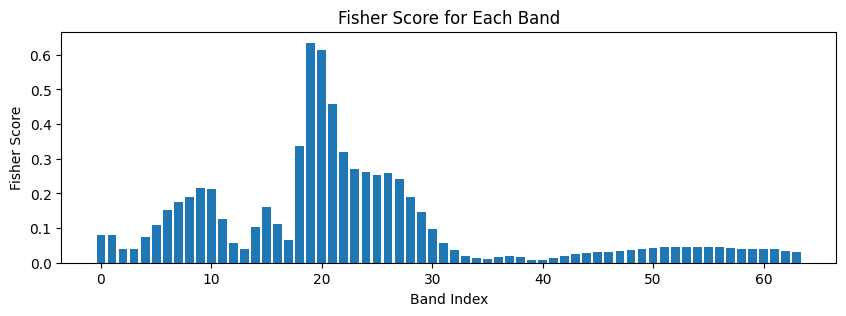

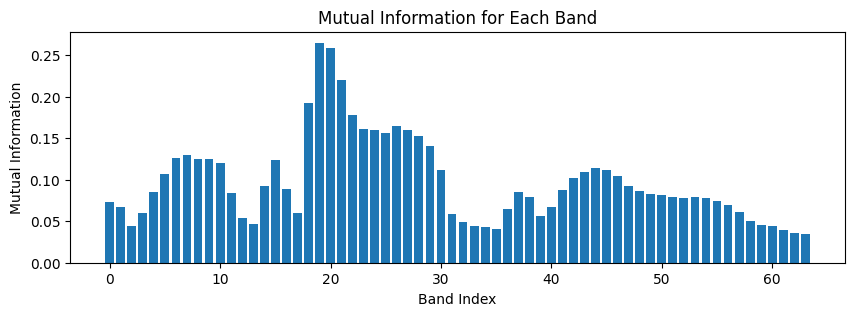

Top 15 Fisher bands: [19 20 21 18 22 23 24 26 25 27  9 10  8 28  7]
Top 15 MI scr bands: [19 20 21 18 22 26 23 24 27 25 28 29  7  6  8]
FisherBand Index:  [7, 8, 9, 10, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28]
MIBand Index:  [6, 7, 8, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29]


In [15]:
print(len(all_real_pixels), '\n',
      all_real_pixels[0].shape,
      all_real_pixels[1].shape,
      all_real_pixels[2].shape)

tprint("fitting norm + pca...")
all_real = np.concatenate(all_real_pixels, axis=0)

labels_all = []
for idx, (data_file, label_file) in enumerate(pairs):
    labels_raw = np.load(label_file).astype(np.int32)
    labels_clipped = np.clip(labels_raw, 0, 8)
    labels = labels_clipped.reshape(-1)
    mask = labels > 0
    labels_all.append(labels[mask])
labels_all = np.concatenate(labels_all, axis=0)

c = all_real.shape[1]
max_fit = 500_000

tprint('randomly sampling for feature selection...')
if len(all_real) > max_fit:
    rng_fit = np.random.RandomState(350235)
    fit_idx = rng_fit.choice(len(all_real), max_fit, replace=False)
    fit_data = all_real[fit_idx]   # shape: (max_fit, c) — independent copy
    fit_labels = labels_all[fit_idx]
else:
    fit_data = all_real
    fit_labels = labels_all
tprint(f"fit_data shape: {fit_data.shape}, fit_labels shape: {fit_labels.shape}")

# Fisher score + MI
fisher_scores = fisher_score(fit_data, fit_labels, n_classes=8)
plt.figure(figsize=(10,3))
plt.bar(range(len(fisher_scores)), fisher_scores)
plt.title('Fisher Score for Each Band')
plt.xlabel('Band Index')
plt.ylabel('Fisher Score')
plt.show()

mi_scores = mutual_info_classif(fit_data, fit_labels, discrete_features=False, random_state=0)
plt.figure(figsize=(10,3))
plt.bar(range(len(mi_scores)), mi_scores)
plt.title('Mutual Information for Each Band')
plt.xlabel('Band Index')
plt.ylabel('Mutual Information')
plt.show()

top_fisher = np.argsort(fisher_scores)[::-1][:15]
top_mi = np.argsort(mi_scores)[::-1][:15]
mi_sort = sorted(top_mi)
fisher_sort = sorted(top_fisher)

print('Top 15 Fisher bands:', top_fisher)
print('Top 15 MI scr bands:', top_mi)
print('FisherBand Index: ', fisher_sort)
print('MIBand Index: ', mi_sort)
c_out = len(mi_sort)

# 3m 17.7s

[14:52:23]   normalization fit on 500,000 non-bg pixels
(64,) 
 (64,)


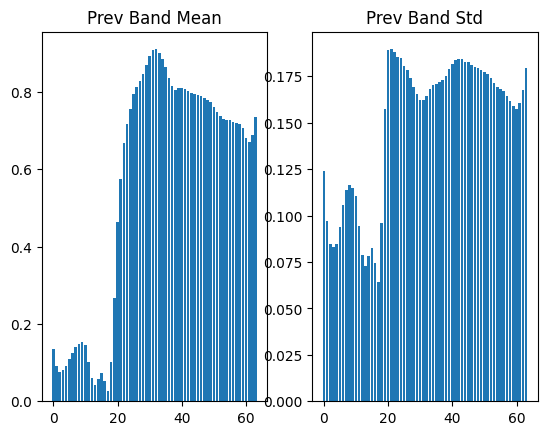

[14:52:26]   pca: 64 -> 15 channels, explained variance: 98.9%, fit on 500,000 pixels


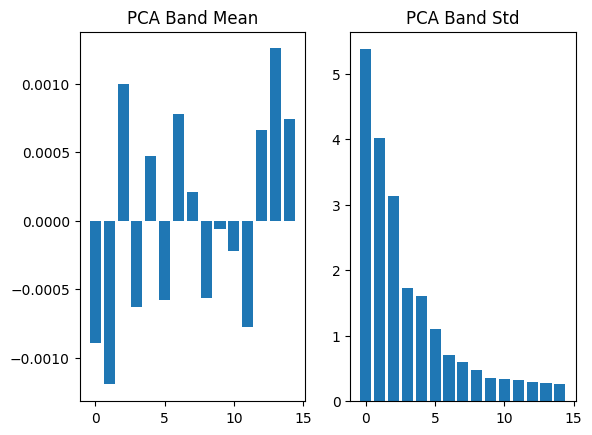

In [16]:
if 'all_real_pixels' in locals() and 'all_real' in locals():
    del all_real_pixels, all_real

# global normalization stats fit on non-bg pixels only
global_mean = fit_data.mean(axis=0).astype(np.float32)       # shape: (c,)
global_std  = fit_data.std(axis=0).astype(np.float32) + 1e-8 # shape: (c,)
tprint(f"  normalization fit on {len(fit_data):,} non-bg pixels")

print(global_mean.shape, '\n', global_std.shape)
ax = plt.subplot(1, 2, 1)
ax.bar(range(len(global_mean)), global_mean)
ax.set_title("Prev Band Mean")
ax = plt.subplot(1, 2, 2)
ax.bar(range(len(global_std)), global_std)
ax.set_title("Prev Band Std")
plt.show()

n_components = config.preprocess.pca_components
pca_obj = None

if n_components and n_components < c:
    normalized_fit = (fit_data - global_mean) / global_std  # shape: (n_fit, c)
    max_pca = 500_000
    if len(normalized_fit) > max_pca:
        rng_pca = np.random.RandomState(42)
        pca_idx = rng_pca.choice(len(normalized_fit), max_pca, replace=False)
        pca_fit = normalized_fit[pca_idx]   # shape: (max_pca, c)
    else:
        pca_fit = normalized_fit            # already within budget

    pca_obj = PCA(n_components=n_components, svd_solver='randomized',
                    random_state=350234)
    pca_obj.fit(pca_fit)
    explained = sum(pca_obj.explained_variance_ratio_) * 100
    tprint(f"  pca: {c} -> {n_components} channels, "
            f"explained variance: {explained:.1f}%, "
            f"fit on {len(pca_fit):,} pixels")

pca_data = normalized_fit @ pca_obj.components_.T  # shape: (n_samples, 32)
pca_mean = pca_data.mean(axis=0)  # shape: (32,)
pca_std = pca_data.std(axis=0)    # shape: (32,)

ax = plt.subplot(1, 2, 1)
ax.bar(range(len(pca_mean)), pca_mean)
ax.set_title("PCA Band Mean")
ax = plt.subplot(1, 2, 2)
ax.bar(range(len(pca_std)), pca_std)
ax.set_title("PCA Band Std")
plt.show()

In [11]:
# del fit_data, normalized_fit, pca_fit

tprint("patient patching...")
_patient_padded_data   = []  # list of padded arrays per patient
_patient_padded_labels = []  # list of padded label maps per patient

all_patch_indices   = []  # each row: (patient_list_idx, row_padded, col_padded)
all_patch_labels    = []  # 0-based center-pixel label
all_patient_groups  = []  # patient group id for each patch

margin = (config.split.patch_size - 1) // 2

for data, label, pid_idx in patient_records[:40]:
    h, w, c_raw = data.shape                     # per-patient: (h_i, w_i, c)
    data = data[:, :, mi_sort]                      # select top MI bands, shape: (h_i, w_i, c_out)
    flat = data.reshape(-1, c_out)               # shape: (h_i * w_i, c)
    # normalize using global stats (fit on non-bg pixels only)
    spatial_mean = global_mean[mi_sort]  # shape: (c_out,)
    spatial_std = global_std[mi_sort]    # shape: (c_out,)
    flat = (flat - spatial_mean) / spatial_std
    
    processed = flat.reshape(h, w, c_out)     # shape: (h_i, w_i, c_out)
    padded_data = _pad_with_zeros(processed, margin)
    # padded shape: (h + 2*margin, w + 2*margin, c_out) 512 -> 556
    
    # pad label: background / padding -> 255 (ignore_index)
    padded_lbl = np.full(
        (h + 2 * margin, w + 2 * margin),
        fill_value=255, dtype=np.int32
    )  # shape: (h_i + 2*margin, w_i + 2*margin)
    lbl_region = label.copy().astype(np.int32)
    lbl_region[lbl_region > 0] -= 1    # 1-based -> 0-based class index
    lbl_region[label == 0] = 255      # background -> ignore
    padded_lbl[margin:margin + h,
                margin:margin + w] = lbl_region

    patient_list_idx = len(_patient_padded_data)
    _patient_padded_data.append(padded_data)
    _patient_padded_labels.append(padded_lbl)

    # extract patch centers: only non-background pixels
    rows, cols = np.where(label > 0)
    n_patches = len(rows)

    # patch_indices: (patient_list_idx, row_in_padded, col_in_padded)
    indices = np.stack([
        np.full(n_patches, patient_list_idx, dtype=np.int32),
        (rows + margin).astype(np.int32),
        (cols + margin).astype(np.int32),
    ], axis=1)   # shape: (n_patches, 3)

    patch_labels = (label[rows, cols] - 1).astype(np.int32)   # shape: (n_patches,)
    patient_groups = np.full(n_patches, pid_idx, dtype=np.int32)

    all_patch_indices.append(indices)
    all_patch_labels.append(patch_labels)
    all_patient_groups.append(patient_groups)
    del data, label, flat, processed, padded_data, padded_lbl

patch_size = 44

patch_indices = np.concatenate(all_patch_indices, axis=0)          # shape: (N, 3)
patch_labels = np.concatenate(all_patch_labels, axis=0)            # shape: (N,)
patch_patient_groups = np.concatenate(all_patient_groups, axis=0)  # shape: (N,)

unique_groups, group_counts = np.unique(
    patch_patient_groups, return_counts=True)
tprint(f"  total patches: {len(patch_indices):,} from "
        f"{len(unique_groups)} patients under {patch_size}^2 patch size.")
print(f"  patches per patient: min={group_counts.min()}, "
        f"max={group_counts.max()}, mean={group_counts.mean():.0f}")
print(f"  patch shape: ({patch_size}, {patch_size}, {c_out}), "
        f"dtype: float32")
print(patch_indices.shape, patch_labels.shape, patch_patient_groups.shape)

[14:45:54] patient patching...


NameError: name 'patient_records' is not defined

In [7]:
if 'patient_records' in locals():
    del patient_records
    
tprint('creating dataLoaders...')
test_rate = 0.2
rng_split = np.random.RandomState(350236)

unique_groups = np.unique(patch_patient_groups)
rng_split.shuffle(unique_groups)
n_test = int(len(unique_groups) * test_rate)

test_groups = unique_groups[:n_test]
train_groups = unique_groups[n_test:]

train_mask = np.isin(patch_patient_groups, train_groups)
test_mask = np.isin(patch_patient_groups, test_groups)

train_indices = patch_indices[train_mask]
train_labels = patch_labels[train_mask]

test_indices = patch_indices[test_mask]
test_labels = patch_labels[test_mask]

tprint(f"  train patches: {len(train_indices)}, test patches: {len(test_indices)}")

train_dataset = PatchDataset(
    train_indices, train_labels,
    _patient_padded_data,
    _patient_padded_labels,
    patch_size)

test_dataset = PatchDataset(
    test_indices, test_labels,
    _patient_padded_data,
    _patient_padded_labels,
    patch_size)

batch_size = config.split.batch_size
pm = torch.cuda.is_available()
prefetch_factor = 2
persistent_workers = True
nw = config.memory.num_workers if torch.cuda.is_available() else 0

train_loader, test_loader = None, None

train_loader = DataLoader(train_dataset, batch_size,
                          shuffle=True, num_workers=nw,
                          pin_memory=pm,
                          prefetch_factor=prefetch_factor if nw > 0 else None,
                          persistent_workers=persistent_workers and (nw > 0),
                          drop_last=True)

test_loader = DataLoader(test_dataset, batch_size,
                         shuffle=False, num_workers=nw,
                         pin_memory=pm,
                         prefetch_factor=prefetch_factor if nw > 0 else None,
                         persistent_workers=persistent_workers and (nw > 0),
                         drop_last=True
                         )

tprint(f"dataLoaders created with batch size {batch_size}\n",
       f"       at train: {train_loader} of {len(train_loader.dataset)} samples\n",
       f"       at test: {test_loader} of {len(test_loader.dataset)} samples")
print(train_loader.dataset[1][0].shape, train_loader.dataset[1][1].shape)

[14:07:35] creating dataLoaders...
[14:07:35]   train patches: 350709, test patches: 91477
[14:07:35] dataLoaders created with batch size 256
        at train: <torch.utils.data.dataloader.DataLoader object at 0x7f69d50dc190> of 350709 samples
        at test: <torch.utils.data.dataloader.DataLoader object at 0x7f6c082b6c70> of 91477 samples
(45, 45, 15) (45, 45)


In [8]:
tprint('initializing model...')

model = CommonViT(
    in_channels=c_out,
    num_classes=config.clsf.num,
    patch_size=patch_size,
    dim=64,
    depths=[2, 2],
    num_heads=[4, 8]
 )

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

if torch.cuda.is_available() and torch.cuda.device_count() > 1:
    model = nn.DataParallel(model)
    tprint(f"model wrapped in DataParallel on {torch.cuda.device_count()} GPUs")

# optimizer
lr = config.common.lr
weight_decay = config.common.weight_decay
optimizer = optim.AdamW(
    model.parameters(), lr=lr,
    weight_decay=weight_decay, betas=(0.9, 0.999))

# lr scheduler
sc = config.common.scheduler
T_0 = getattr(sc, 'T_0', 10)
T_mult = getattr(sc, 'T_mult', 2)
eta_min = getattr(sc, 'eta_min', 1e-6)
scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=T_0, T_mult=T_mult, eta_min=eta_min)

import tqdm
all_train_labels = []
for i in tqdm.tqdm(range(20), desc="Count from 20 samplers"):
    patient_idx, row, col = train_indices[i]
    label_patch = _patient_padded_labels[patient_idx][row - patch_size//2 : row + patch_size//2 + 1, col - patch_size//2 : col + patch_size//2 + 1]
    all_train_labels.append(label_patch.flatten())

all_train_labels = np.concatenate(all_train_labels, axis=0)
class_counts = np.bincount(all_train_labels[all_train_labels != 255], minlength=config.clsf.num)
print(f"  class counts (train set): {class_counts}")


class_weights = class_counts / class_counts.sum()
class_weights = -0.01 * np.log(class_weights + 1e-8)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor, ignore_index=255)
print(f"  AdamW(lr={lr}, wd={weight_decay}) + CosineWR(T0={T_0}, Tm={T_mult})\n"
      f" class weights: {class_weights.round(4)}")

[14:07:35] initializing model...
StandardHSITransformer initialized with 15 input channels, 8 classes, depths [2, 2], 44 patch_size.
StandardHSITransformer initialized successfully.
[14:07:36] model wrapped in DataParallel on 4 GPUs


Count from 20 samplers: 100%|██████████| 20/20 [00:00<00:00, 41610.16it/s]

  class counts (train set): [    0     0     0     0 11378     0     0     0]
  AdamW(lr=0.0001, wd=0.1) + CosineWR(T0=5, Tm=2)
 class weights: [ 0.1842  0.1842  0.1842  0.1842 -0.      0.1842  0.1842  0.1842]


In [9]:
tprint("training loop starting...")

num_epochs = 10
best_test_acc = 0.0
train_losses, test_losses = [], []
train_acc, test_acc = [], []

for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0
    
    patches, label_patches = None, None
    for patches, label_patches in tqdm.tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} - Train"):
        patches = patches.to(device)
        label_patches = label_patches.to(device).long()
        
        patches = patches.permute(0, 3, 1, 2)  # shape: (B, c_out, H, W)
        label_patches = label_patches.permute(0, 2, 1)  # shape: (B, H, W)
        
        optimizer.zero_grad()
        outputs = model(patches)  # shape: (B, num_classes, H, W)
        
        # label_patches: (B, H, W)
        loss = criterion(outputs, label_patches)
        loss.backward()
        
        optimizer.step()
        train_loss += loss.item() * label_patches.numel()
        
        # pixel acc
        _, predicted = outputs.max(1)  # shape: (B, H, W)
        mask = (label_patches != 255)
        train_correct += (predicted[mask] == label_patches[mask]).sum().item()
        train_total += mask.sum().item()
        
    scheduler.step()
    
    train_acc_epoch = train_correct / train_total if train_total > 0 else 0
    avg_train_loss = train_loss / train_total if train_total > 0 else 0
    train_losses.append(avg_train_loss)
    train_acc.append(train_acc_epoch)
    
    # # Evaluation
    model.eval()
    test_loss = 0.0
    test_correct = 0
    test_total = 0
    
    with torch.no_grad():
        for patches, label_patches in tqdm.tqdm(test_loader, desc=f"Epoch {epoch+1}/{num_epochs} - Test"):
            patches = patches.to(device)
            label_patches = label_patches.to(device).long()
            
            patches = patches.permute(0, 3, 1, 2)  # shape: (B, c_out, H, W)
            label_patches = label_patches.permute(0, 2, 1)  # shape: (B, H, W)
            
            outputs = model(patches)
            loss = criterion(outputs, label_patches)
            test_loss += loss.item() * label_patches.numel()
            
            _, predicted = outputs.max(1)
            mask = (label_patches != 255)
            test_correct += (predicted[mask] == label_patches[mask]).sum().item()
            test_total += mask.sum().item()
            
    test_acc_epoch = test_correct / test_total if test_total > 0 else 0
    avg_test_loss = test_loss / test_total if test_total > 0 else 0
    test_losses.append(avg_test_loss)
    test_acc.append(test_acc_epoch)
    
    if test_acc_epoch > best_test_acc:
        best_test_acc = test_acc_epoch
        
    tprint(f"Epoch {epoch+1}/{num_epochs} - "
           f"Train Loss: {avg_train_loss:.4f}, Train Acc: {train_acc_epoch:.4f} - "
           f"Test Loss: {avg_test_loss:.4f}, Test Acc: {test_acc_epoch:.4f} (Best: {best_test_acc:.4f})")

[14:07:36] training loop starting...


Epoch 1/10 - Test: 100%|██████████| 357/357 [00:33<00:00, 10.79it/s]


[14:14:16] Epoch 1/10 - Train Loss: 0.1364, Train Acc: 0.8143 - Test Loss: 3.9041, Test Acc: 0.3532 (Best: 0.3532)


Epoch 2/10 - Test: 100%|██████████| 357/357 [00:34<00:00, 10.41it/s]


[14:20:54] Epoch 2/10 - Train Loss: 0.0124, Train Acc: 0.8300 - Test Loss: 3.8659, Test Acc: 0.5169 (Best: 0.5169)


...

[14:35:01] Epoch 4/10 - Train Loss: 0.0026, Train Acc: 0.8311 - Test Loss: 4.7000, Test Acc: 0.4657 (Best: 0.5169)


Epoch 5/10 - Test: 100%|██████████| 357/357 [00:45<00:00,  7.77it/s]


[14:42:01] Epoch 5/10 - Train Loss: 0.0011, Train Acc: 0.8314 - Test Loss: 5.0937, Test Acc: 0.4610 (Best: 0.5169)


Epoch 6/10 - Train:  40%|███▉      | 544/1369 [03:05<04:41,  2.93it/s]


KeyboardInterrupt: 

In [ ]:
print(loss)
print(train_acc, '\n', test_acc, '\n', train_losses, '\n', test_losses)

In [ ]:
tprint('Plotting training curves...')
import seaborn as sns
from sklearn.metrics import (accuracy_score, balanced_accuracy_score,
        cohen_kappa_score,
        confusion_matrix as _cm, roc_curve,
        precision_recall_fscore_support, auc)

plt.figure(figsize=(12,5))
plt.subplot(1, 2, 1)
plt.plot(train_acc, label='Train Acc')
plt.plot(test_acc, label='Test Acc')
plt.xlabel('Epoch')
plt.ylabel('Pixel Accuracy')
plt.title('Training Curves')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(train_losses, label='Train Loss')
plt.plot(test_losses, label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss Curves')
plt.legend()
plt.tight_layout()
plt.show()

tprint('Plotting confusion matrix...')
model.eval()
all_preds = []
all_labels = []
with torch.no_grad():
    for patches, label_patches in tqdm.tqdm(test_loader, desc="Collecting predictions for confusion matrix"):
        patches = patches.to(device)
        label_patches = label_patches.to(device).long()
        
        patches = patches.permute(0, 3, 1, 2)  # shape: (B, c_out, H, W)
        label_patches = label_patches.permute(0, 2, 1)
        
        outputs = model(patches)
        _, predicted = outputs.max(1)
        mask = (label_patches != 255)
        all_preds.append(predicted[mask].cpu().numpy())
        all_labels.append(label_patches[mask].cpu().numpy())
        
all_preds = np.concatenate(all_preds)
all_labels = np.concatenate(all_labels)
cm = _cm(all_labels, all_preds, labels=config.clsf.targets)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

tprint('Calculating classification report...')
acc = accuracy_score(all_labels, all_preds)
balanced_acc = balanced_accuracy_score(all_labels, all_preds)
kappa = cohen_kappa_score(all_labels, all_preds)
precision, recall, f1, _ = precision_recall_fscore_support(
    all_labels, all_preds, average='weighted')
print(f"Accuracy: {acc:.4f}")
print(f"Balanced Accuracy: {balanced_acc:.4f}")
print(f"Cohen's Kappa: {kappa:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

tprint('Plotting ROC curves...')
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_auc_score
# Binarize labels for multi-class ROC
y_true_bin = label_binarize(all_labels, classes=config.clsf.targets)
y_score_bin = np.zeros_like(y_true_bin, dtype=np.float32)
idx = 0
with torch.no_grad():
    for patches, label_patches in tqdm.tqdm(test_loader, desc="Collecting probabilities for ROC curves"):
        patches = patches.to(device)
        label_patches = label_patches.to(device).long()
        
        patches = patches.permute(0, 3, 1, 2)  # shape: (B, c_out, H, W)
        label_patches = label_patches.permute(0, 2, 1)
        
        outputs = model(patches)
        probs = torch.softmax(outputs, dim=1)
        mask = (label_patches != 255)
        y_score_bin[idx:idx+mask.sum()] = probs.permute(0, 2, 3, 1)[mask].cpu().numpy()
        idx += mask.sum()
# Compute ROC curve and AUC for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(config.clsf.num):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_score_bin[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
# Plot ROC curves
plt.figure(figsize=(8,6))
for i in range(config.clsf.num):
    plt.plot(fpr[i], tpr[i], label=f'Class {i} (AUC = {roc_auc[i]:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend()
plt.show()